✅ Successfully loaded 'processed_data.pkl'.

--- Stage 1: Wrapper-based Feature Selection ---

🔄 Starting RFECV with XGBClassifier...
✅ RFECV complete. Optimal number of features found: 26
   - Selected features are: 
['rpm', 'Mean', 'RMS', 'Var', 'Skew', 'Kurt', 'CF', 'MF', 'P2P', 'FreqMean', 'FreqSTD', 'FreqSkew', 'FreqKurt', 'IR_Sideband_Energy_DE', 'IR_Sideband_Ratio_DE', 'B_Sideband_Energy_DE', 'B_Sideband_Ratio_DE', 'IR_Sideband_Energy_FE', 'IR_Sideband_Ratio_FE', 'B_Sideband_Energy_FE', 'B_Sideband_Ratio_FE', 'Env_Peak_BPFI_DE', 'Env_Peak_BSF_DE', 'Env_Peak_BPFO_FE', 'Env_Peak_BPFI_FE', 'Env_Peak_BSF_FE']

--- Stage 2: Model Comparison (After Feature Selection) ---

Model Performance Comparison (After Feature Selection):
               Train_Accuracy_Mean  Validation_Accuracy_Mean
Model                                                       
Random Forest               1.0000                    0.8905
AdaBoost                    0.1445                    0.1423
XGBoost           

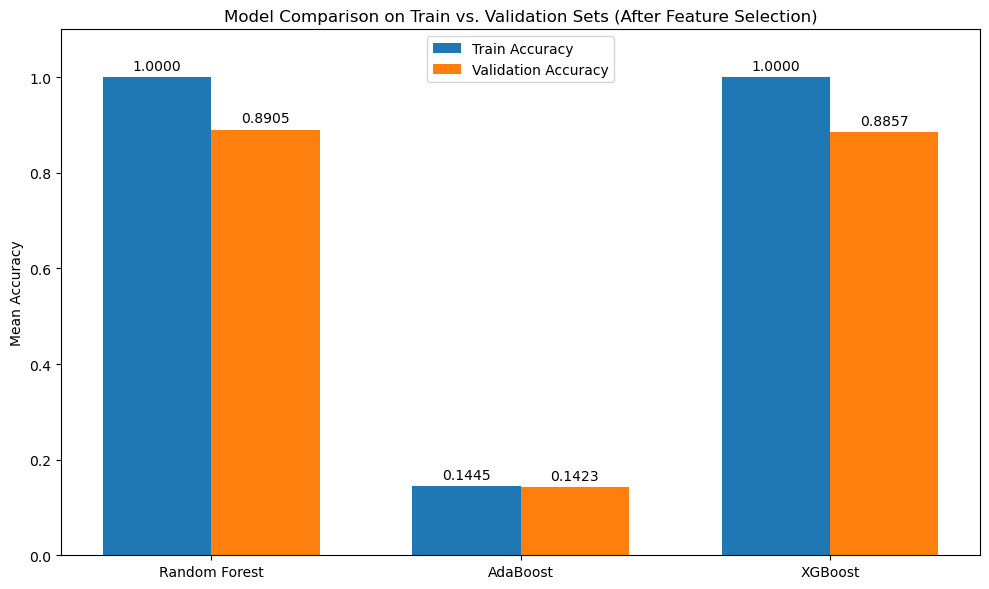


🏆 Based on mean validation accuracy, the best model is: **Random Forest**

--- Stage 3: Final Training and Evaluation (Random Forest) ---
✅ Final model training complete.

--- Final Model Performance on Test Set ---
✅ Accuracy: 0.9119

📋 Classification Report:
              precision    recall  f1-score   support

     DE_B_14       0.94      0.85      0.89        20
     DE_B_21       0.82      0.90      0.86        20
     DE_B_28       1.00      1.00      1.00        20
      DE_B_7       0.74      1.00      0.85        20
    DE_IR_14       0.86      0.95      0.90        20
    DE_IR_21       1.00      0.75      0.86        20
    DE_IR_28       0.91      1.00      0.95        20
     DE_IR_7       0.86      0.95      0.90        20
    DE_OR_14       0.95      1.00      0.98        20
    DE_OR_21       0.89      0.80      0.84        20
     DE_OR_7       0.89      0.40      0.55        20
     FE_B_14       1.00      1.00      1.00        20
     FE_B_21       1.00      0.95  

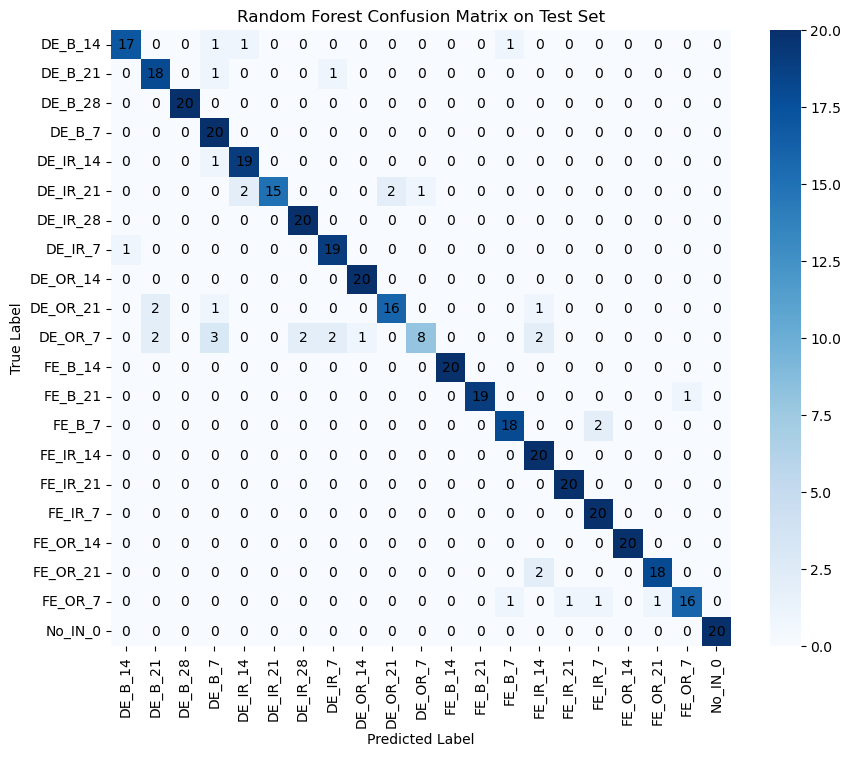


🔄 Generating feature importance chart for Random Forest...


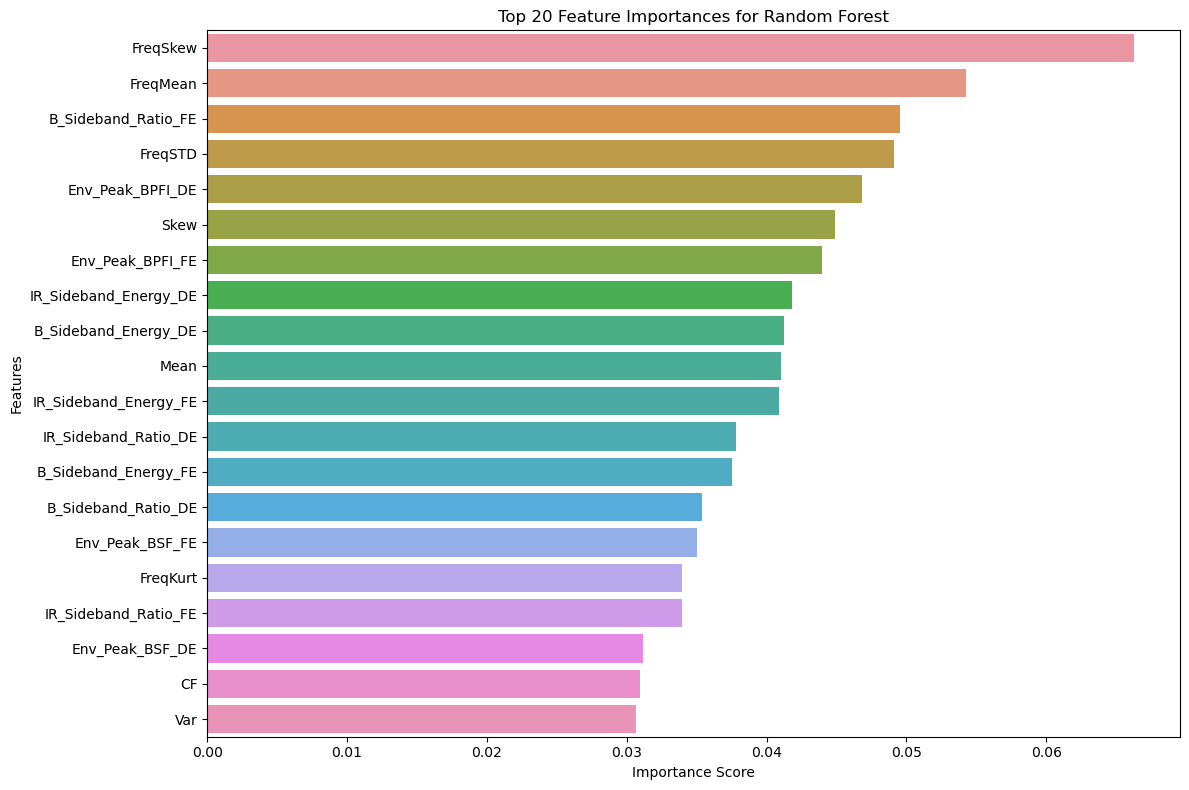


✅ Trained model has been saved to: 'random_forest_final_model.pkl'

--- Stage 4: Predicting on Target Domain Data ---
✅ Successfully loaded 'processed_data - target.pkl'.

🔄 Aligning target data with the 26 selected features...
✅ Target data aligned. Shape: (16, 26)

🔄 Predicting with the final Random Forest model...

🎉 --- Target Domain Prediction Complete --- 🎉
Final Predictions:
    Sample_Index Predicted_Label
0              0         DE_B_14
1              1        DE_OR_21
2              2         DE_B_28
3              3         FE_B_14
4              4         DE_B_28
5              5        FE_IR_14
6              6         DE_B_14
7              7         DE_B_28
8              8        DE_IR_21
9              9         DE_B_28
10            10         No_IN_0
11            11         No_IN_0
12            12         DE_B_14
13            13         DE_B_28
14            14         DE_B_14
15            15         FE_B_14

✅ Predictions have been saved to 'target_domain_pred

KeyboardInterrupt: 

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

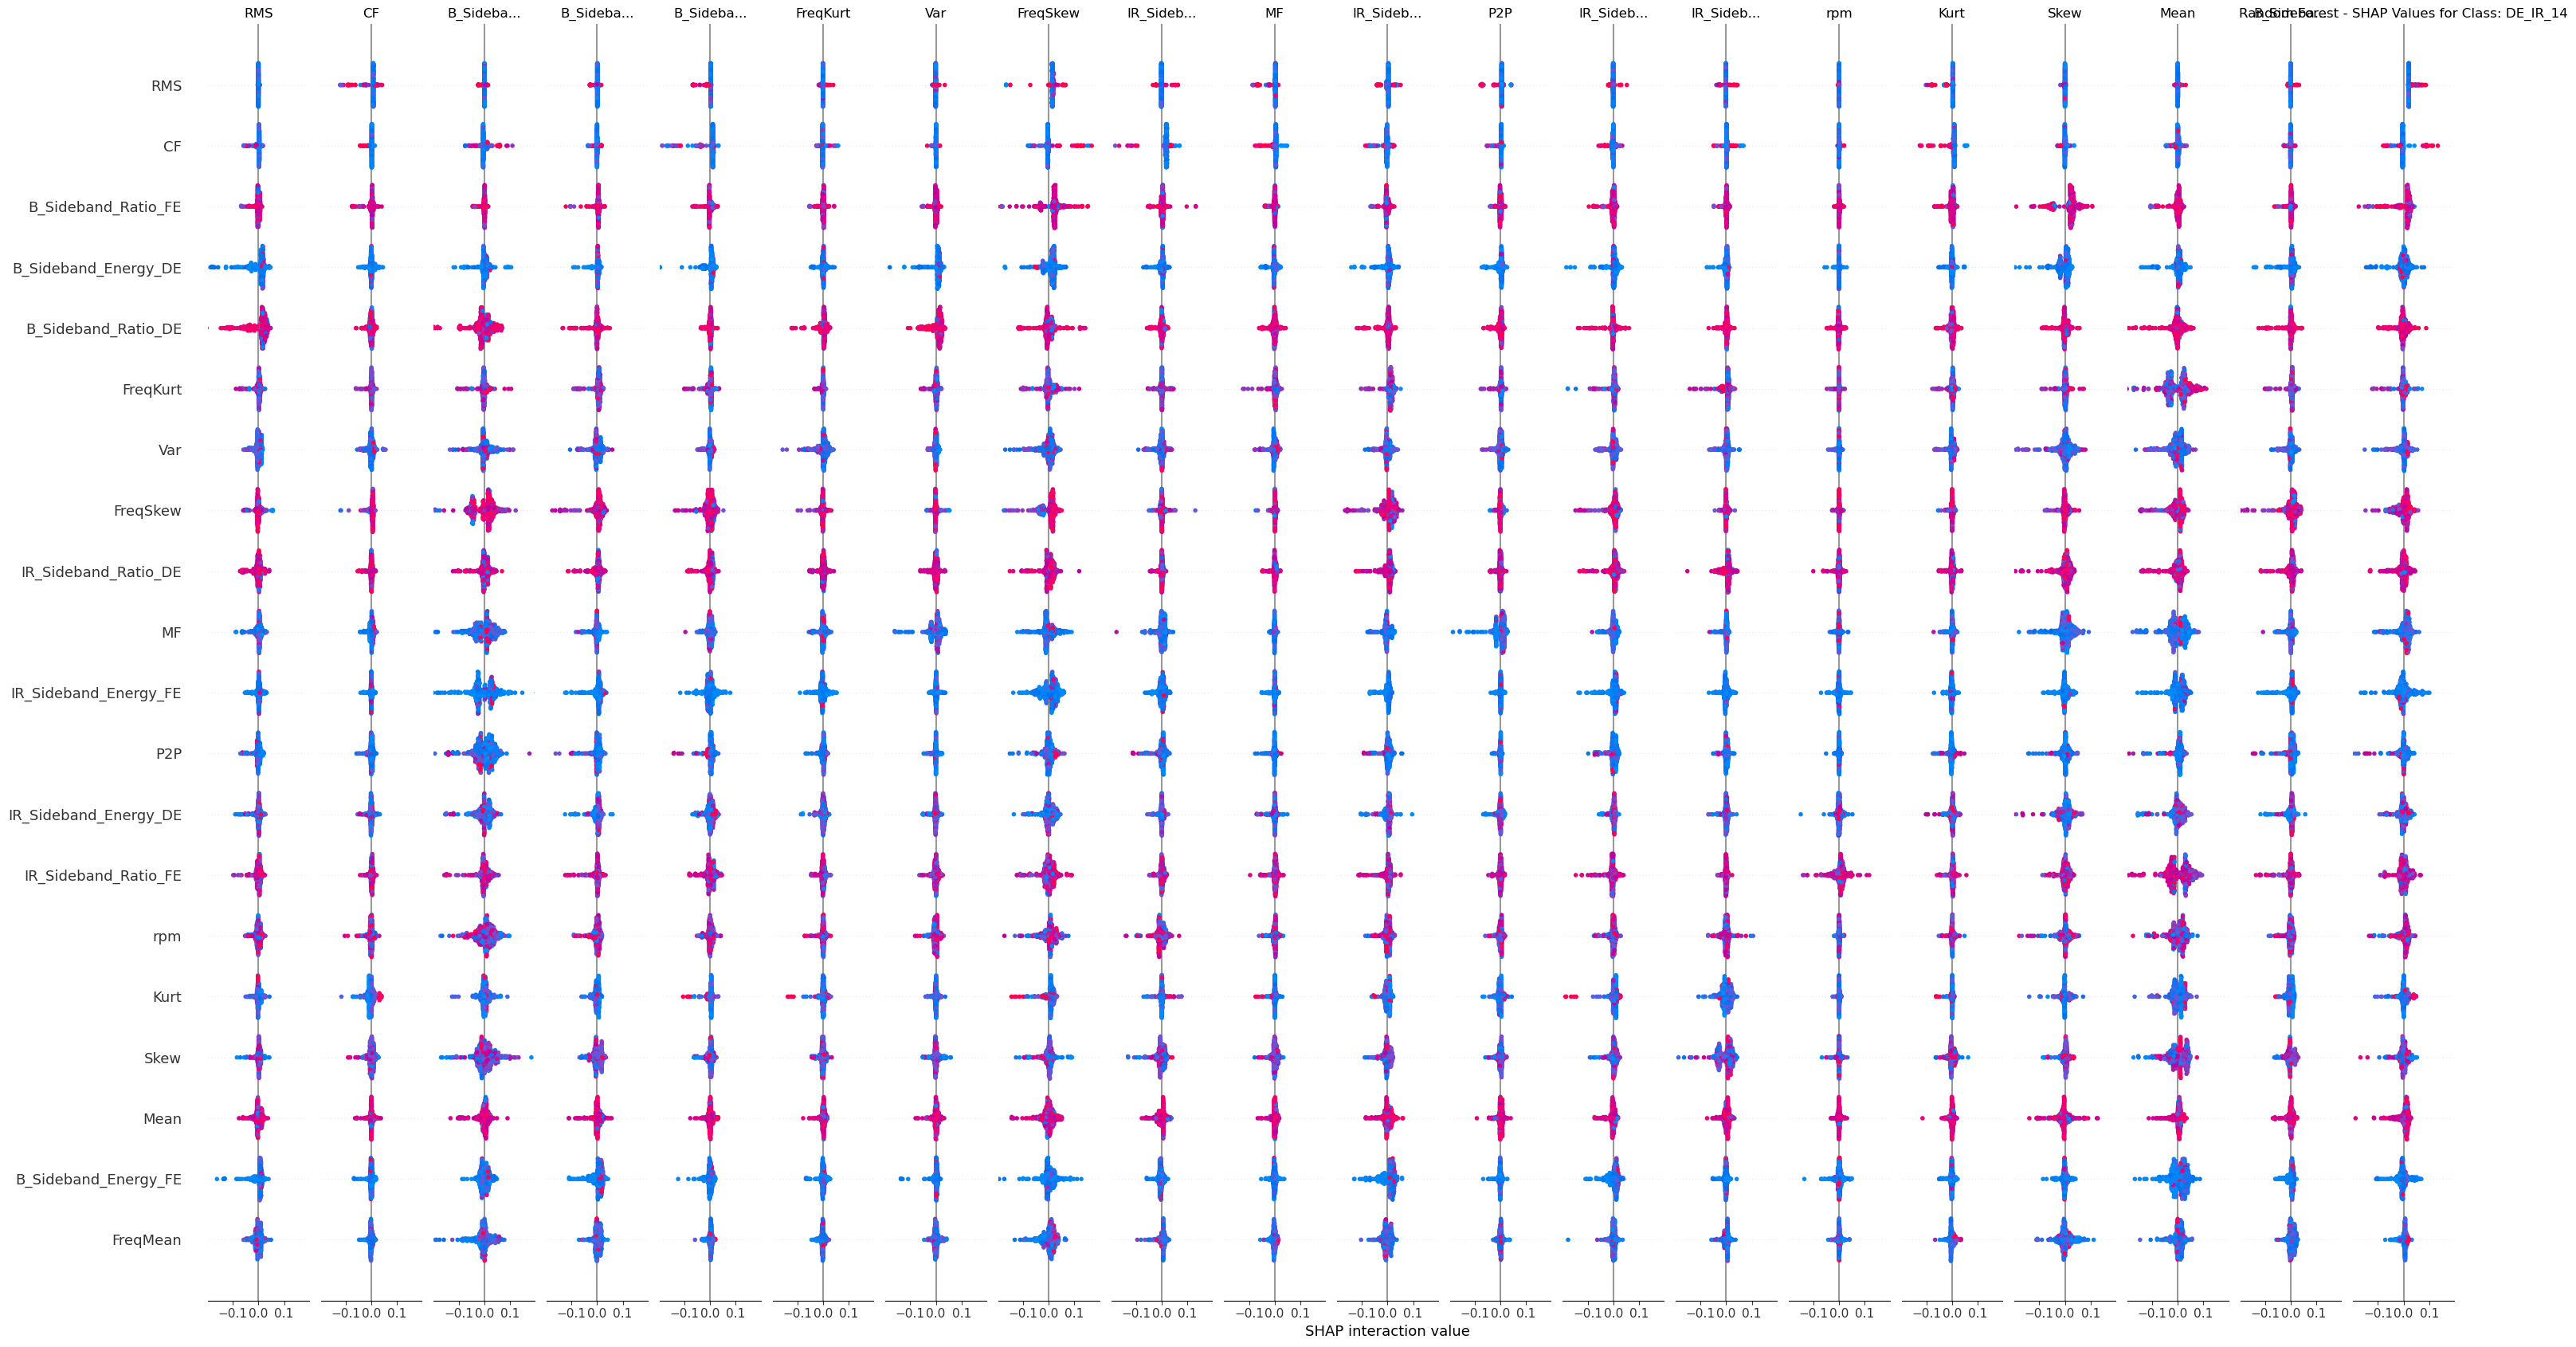

In [4]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

# 忽略一些可能出现的计算警告
warnings.filterwarnings('ignore')

# --- 绘图函数 ---
def plot_comparison_chart(results_df, title_suffix=""):
    print(f"\n🔄 Generating model comparison chart{title_suffix}...")
    train_acc = results_df['Train_Accuracy_Mean']
    validation_acc = results_df['Validation_Accuracy_Mean']
    model_names = results_df.index
    x = np.arange(len(model_names)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy')
    rects2 = ax.bar(x + width/2, validation_acc, width, label='Validation Accuracy')
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Model Comparison on Train vs. Validation Sets{title_suffix}')
    ax.set_xticks(x); ax.set_xticklabels(model_names); ax.legend()
    ax.bar_label(rects1, padding=3, fmt='%.4f'); ax.bar_label(rects2, padding=3, fmt='%.4f')
    ax.set_ylim(0, 1.1); fig.tight_layout()
    plt.savefig(f'../results/02_迁移诊断/model_comparison_accuracy{title_suffix.replace(" ", "_")}.png')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    print("\n🔄 Generating confusion matrix chart...")
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color="black", size=10)
    ax.set_title(f'{model_name} Confusion Matrix on Test Set'); ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_confusion_matrix.png')
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    print(f"\n🔄 Generating feature importance chart for {model_name}...")
    if not hasattr(model, 'feature_importances_'): return
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_features = feature_importance_df.head(20)
    plt.figure(figsize=(12, 8)); sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top {len(top_features)} Feature Importances for {model_name}'); plt.xlabel('Importance Score'); plt.ylabel('Features')
    plt.tight_layout(); plt.savefig(f'../results/02_迁移诊断/{model_name.replace(" ", "_").lower()}_feature_importance.png')
    plt.show()

# --- 主要实验函数 ---
def select_features_with_rfecv(X_train, y_train, model_for_selection, kfold):
    print("\n--- Stage 1: Wrapper-based Feature Selection ---")
    print(f"\n🔄 Starting RFECV with {type(model_for_selection).__name__}...")
    rfecv = RFECV(estimator=model_for_selection, step=1, cv=kfold, scoring="f1_weighted", min_features_to_select=5, n_jobs=-1)
    rfecv.fit(X_train, y_train)
    print(f"✅ RFECV complete. Optimal number of features found: {rfecv.n_features_}")
    selected_features = X_train.columns[rfecv.support_]
    print(f"   - Selected features are: \n{selected_features.tolist()}")
    X_train_selected = rfecv.transform(X_train)
    return pd.DataFrame(X_train_selected, index=X_train.index, columns=selected_features), selected_features

def compare_models_via_cv(X_train, y_train, models, kfold, title_suffix=""):
    print(f"\n--- Stage 2: Model Comparison{title_suffix} ---")
    results = []
    for model_name, model in models.items():
        cv_results = cross_validate(model, X_train, y_train, cv=kfold, scoring=['accuracy'], n_jobs=-1, return_train_score=True)
        model_result = {'Model': model_name, 'Train_Accuracy_Mean': cv_results['train_accuracy'].mean(), 'Validation_Accuracy_Mean': cv_results['test_accuracy'].mean()}
        results.append(model_result)
    results_df = pd.DataFrame(results).set_index('Model')
    print(f"\nModel Performance Comparison{title_suffix}:\n{results_df.round(4).to_string()}")
    plot_comparison_chart(results_df, title_suffix)
    best_model_name = results_df['Validation_Accuracy_Mean'].idxmax()
    print(f"\n🏆 Based on mean validation accuracy, the best model is: **{best_model_name}**")
    return best_model_name

def train_and_evaluate_final_model(model, model_name, X_train, y_train, X_test, y_test, le):
    print(f"\n--- Stage 3: Final Training and Evaluation ({model_name}) ---")
    model.fit(X_train, y_train)
    print("✅ Final model training complete.")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Final Model Performance on Test Set ---\n✅ Accuracy: {accuracy:.4f}")
    y_test_text, y_pred_text = le.inverse_transform(y_test), le.inverse_transform(y_pred)
    print("\n📋 Classification Report:"); print(classification_report(y_test_text, y_pred_text))
    plot_confusion_matrix(y_test_text, y_pred_text, class_names=le.classes_, model_name=model_name)
    plot_feature_importance(model, X_train.columns, model_name)
    model_filename = f'../models/target/{model_name.replace(" ", "_").lower()}_final_model.pkl'
    with open(model_filename, 'wb') as f: pickle.dump(model, f)
    print(f"\n✅ Trained model has been saved to: '{model_filename}'")
    return model

def predict_target_domain(model, model_name, target_data_path, selected_features, le):
    print("\n" + "="*50 + f"\n--- Stage 4: Predicting on Target Domain Data ---")
    try:
        with open(target_data_path, 'rb') as f:
            target_data_bundle = pickle.load(f)
        X_target = target_data_bundle['X_target']
        print(f"✅ Successfully loaded '{target_data_path}'.")
    except FileNotFoundError:
        print(f"❌ Error: Target data file '{target_data_path}' not found."); return
        
    print(f"\n🔄 Aligning target data with the {len(selected_features)} selected features...")
    X_target_selected = X_target[selected_features]
    print(f"✅ Target data aligned. Shape: {X_target_selected.shape}")
    print(f"\n🔄 Predicting with the final {model_name} model...")
    target_predictions_encoded = model.predict(X_target_selected)
    target_predictions_text = le.inverse_transform(target_predictions_encoded)
    predictions_df = pd.DataFrame({'Sample_Index': X_target.index, 'Predicted_Label': target_predictions_text})
    print("\n🎉 --- Target Domain Prediction Complete --- 🎉\nFinal Predictions:")
    print(predictions_df.to_string())
    output_filename = '../results/预测结果/target_domain_predictions.csv'
    predictions_df.to_csv(output_filename, index=False)
    print(f"\n✅ Predictions have been saved to '{output_filename}'")


# --- 修正后的SHAP分析函数 ---
def analyze_with_shap_beeswarm(model, model_name, X_data, class_names):
    """
    使用SHAP为多分类模型生成蜂群图，展示单个特征与每个标签之间的关系
    
    参数:
    model: 训练好的模型
    model_name: 模型名称（用于保存文件）
    X_data: 用于解释的数据（如测试集）
    class_names: 类别名称列表
    """
    print(f"\n开始为{model_name}生成SHAP蜂群图（单特征-标签关系）...")
    
    try:
        # 创建TreeExplainer（适用于树模型）
        explainer = shap.TreeExplainer(model)
        
        # 计算SHAP值
        shap_values = explainer.shap_values(X_data)
        
        # 获取特征名称
        feature_names = X_data.columns.tolist()
        
        # 检查是多分类还是二分类
        if isinstance(shap_values, list):
            # 多分类：shap_values是列表，每个元素对应一个类别
            num_classes = len(shap_values)
            print(f"检测到多分类问题，共有 {num_classes} 个类别")
            
            # 为每个类别生成蜂群图
            for class_idx, class_name in enumerate(class_names):
                print(f"正在生成类别 '{class_name}' 的SHAP蜂群图...")
                
                # 创建图形
                plt.figure(figsize=(12, 10))
                
                # 绘制蜂群图 - 注意：不使用plot_type参数，默认生成蜂群图
                shap.summary_plot(
                    shap_values[class_idx], 
                    X_data, 
                    feature_names=feature_names,
                    show=False,
                    max_display=min(20, len(feature_names))
                )
                
                plt.title(f'{model_name} - SHAP Values for Class: {class_name}')
                plt.tight_layout()
                
                # 保存图像
                filename = f"../results/shap/{model_name.replace(' ', '_')}_shap_beeswarm_{class_name}.png"
                plt.savefig(filename, dpi=300, bbox_inches='tight')
                plt.close()
                
                print(f"已保存: {filename}")
                
        else:
            # 二分类问题处理
            print("检测到二分类问题")
            for class_idx, class_name in enumerate(class_names):
                print(f"正在生成类别 '{class_name}' 的SHAP蜂群图...")
                
                plt.figure(figsize=(12, 10))
                
                # 二分类需要特殊处理SHAP值
                if class_idx == 0:
                    class_shap_values = shap_values
                else:
                    class_shap_values = -shap_values
                
                shap.summary_plot(
                    class_shap_values, 
                    X_data, 
                    feature_names=feature_names,
                    show=False,
                    max_display=min(20, len(feature_names))
                )
                
                plt.title(f'{model_name} - SHAP Values for Class: {class_name}')
                plt.tight_layout()
                
                filename = f"../results/shap/{model_name.replace(' ', '_')}_shap_beeswarm_{class_name}.png"
                plt.savefig(filename, dpi=300, bbox_inches='tight')
                plt.close()
                
                print(f"已保存: {filename}")
                
        print("所有SHAP蜂群图生成完成！")
        
    except Exception as e:
        print(f"SHAP分析过程中出错: {e}")
        import traceback
        traceback.print_exc()

# 使用示例
# analyze_with_shap_beeswarm(
#     model=your_trained_model,
#     model_name="Random_Forest",
#     X_data=X_test,  # 测试集数据
#     class_names=le.classes_  # 标签编码器的类别名称
# )


# --- 主执行函数 ---
if __name__ == "__main__":
    
    # 加载数据
    try:
        with open('../data/processed/processed_data - 2.pkl', 'rb') as f:
            data_bundle = pickle.load(f)
        X_train_full, y_train_text, X_test_full, y_test_text = (
            data_bundle['X_train'], data_bundle['y_train'], 
            data_bundle['X_test'], data_bundle['y_test']
        )
        print(f"✅ Successfully loaded '../data/processed/processed_data.pkl'.")
    except FileNotFoundError:
        print("❌ Error: Data file '../data/processed/processed_data.pkl' not found.")
        exit()

    # 标签编码
    le = LabelEncoder()
    le.fit(pd.concat([y_train_text, y_test_text]).unique())
    y_train_encoded, y_test_encoded = le.transform(y_train_text), le.transform(y_test_text)
    
    # 定义模型
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    }
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 阶段 1: 特征选择
    model_for_fs = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False)
    X_train_selected, selected_feature_names = select_features_with_rfecv(
        X_train_full, y_train_encoded, model_for_fs, kfold
    )
    X_test_selected = X_test_full[selected_feature_names]

    # 阶段 2: 在筛选后的特征上重新比选模型
    best_model_name_after_fs = compare_models_via_cv(
        X_train_selected, y_train_encoded, models, kfold, title_suffix=" (After Feature Selection)"
    )

    # 阶段 3: 训练、评估并保存最终模型
    final_trained_model = train_and_evaluate_final_model(
        model=models[best_model_name_after_fs],
        model_name=best_model_name_after_fs,
        X_train=X_train_selected,
        y_train=y_train_encoded,
        X_test=X_test_selected,
        y_test=y_test_encoded,
        le=le
    )

    # 阶段 4: 对目标域数据进行预测
    predict_target_domain(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        target_data_path='../data/processed/processed_data - target.pkl',
        selected_features=selected_feature_names,
        le=le
    )
    
    # **【最终阶段】**: 对最终模型进行SHAP可解释性分析
    analyze_with_shap(
        model=final_trained_model,
        model_name=best_model_name_after_fs,
        X_data=X_test_selected,  # 使用测试集数据
        class_names=le.classes_
    )